In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

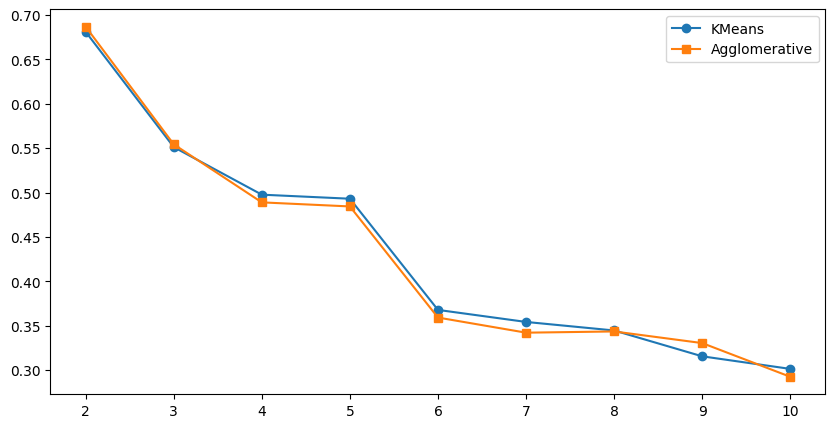

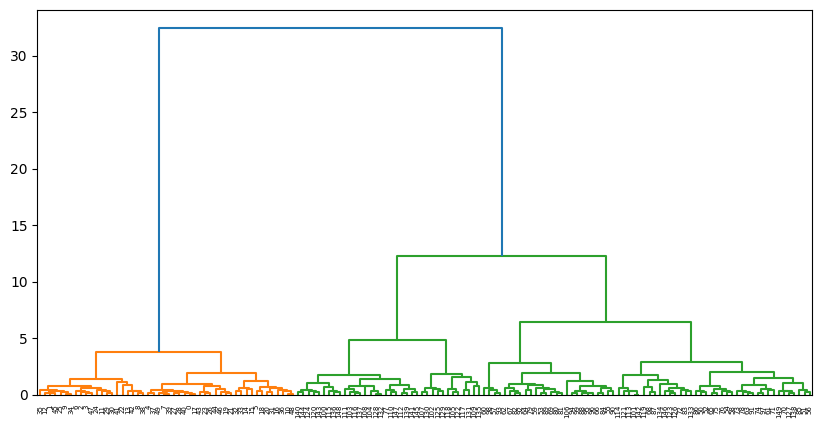

0.48603419703456857


In [9]:
iris = load_iris()
X = iris.data

ks = range(2, 11)
km_scores = []
agg_scores = []

for k in ks:
    km = KMeans(n_clusters=k, n_init='auto', random_state=42).fit(X)
    km_scores.append(silhouette_score(X, km.labels_))
    
    agg = AgglomerativeClustering(n_clusters=k).fit(X)
    agg_scores.append(silhouette_score(X, agg.labels_))

plt.figure(figsize=(10, 5))
plt.plot(ks, km_scores, 'o-', label='KMeans')
plt.plot(ks, agg_scores, 's-', label='Agglomerative')
plt.legend()
plt.show()

linked = linkage(X, 'ward')
plt.figure(figsize=(10, 5))
dendrogram(linked)
plt.show()

db = DBSCAN(eps=0.5, min_samples=5).fit(X)
if len(np.unique(db.labels_)) > 1:
    print(silhouette_score(X, db.labels_))